In [27]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB

In [28]:
# Load dataset (replace with your file path)
df = pd.read_csv(r"D:\Sem 4\ML\ml project\data\diabetic_data.csv")# Inspect first few rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [29]:
# Check missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Drop columns you don't need (replace 'unwanted_column' with actual column name)
df = df.drop(columns=['unwanted_column'], errors='ignore')

Missing values before cleaning:
 encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride    

In [30]:
# Fill missing values with mode for each column
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Check again
print("Missing values after cleaning:\n", df.isnull().sum())


C:\Users\Ashok\AppData\Local\Temp\ipykernel_30528\2221053184.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


Missing values after cleaning:
 encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride     

In [31]:
# Replace 'target_column' with your actual target variable
X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [32]:
from sklearn.preprocessing import LabelEncoder

# Fill numeric columns with median
for col in X.select_dtypes(include=[np.number]).columns:
    X[col].fillna(X[col].median(), inplace=True)

# Fill categorical columns with mode
for col in X.select_dtypes(include=['object']).columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

# Encode categorical columns into numbers
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

C:\Users\Ashok\AppData\Local\Temp\ipykernel_30528\3245666657.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X[col].fillna(X[col].median(), inplace=True)
C:\Users\Ashok\AppData\Local\Temp\ipykernel_30528\3245666657.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

KNN Accuracy: 0.5064854241729446
Classification Report:
               precision    recall  f1-score   support

         <30       0.19      0.11      0.14      3407
         >30       0.41      0.45      0.43     10664
          NO       0.60      0.63      0.62     16459

    accuracy                           0.51     30530
   macro avg       0.40      0.39      0.39     30530
weighted avg       0.49      0.51      0.50     30530



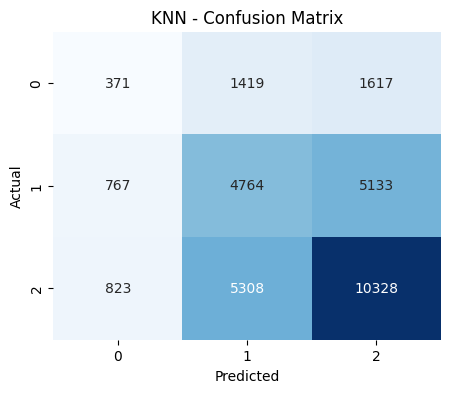

In [57]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
results["KNN"] = acc_knn

Decision Tree Accuracy: 0.5795610874549624
Classification Report:
               precision    recall  f1-score   support

         <30       0.44      0.02      0.03      3407
         >30       0.49      0.35      0.41     10664
          NO       0.61      0.84      0.71     16459

    accuracy                           0.58     30530
   macro avg       0.51      0.40      0.38     30530
weighted avg       0.55      0.58      0.53     30530



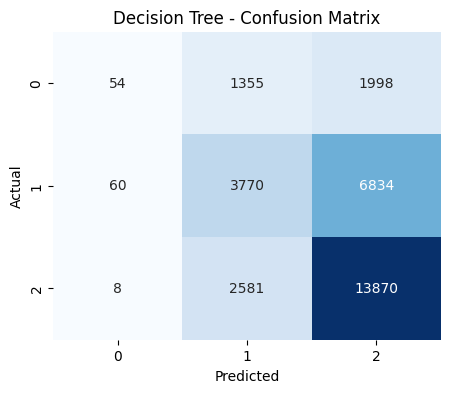

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)   # adjust max_depth manually
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc_dt)
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Store accuracy in results dictionary
results["Decision Tree"] = acc_dt

Logistic Regression Accuracy: 0.5761546020307894
Classification Report:
               precision    recall  f1-score   support

         <30       0.38      0.01      0.02      3407
         >30       0.50      0.30      0.37     10664
          NO       0.60      0.87      0.71     16459

    accuracy                           0.58     30530
   macro avg       0.49      0.39      0.37     30530
weighted avg       0.54      0.58      0.51     30530



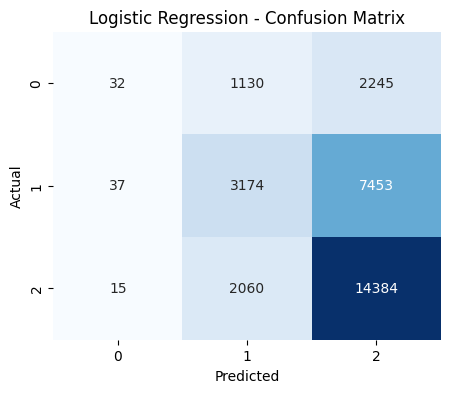

In [59]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, solver='saga', random_state=42)   # try different solvers/penalties
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", acc_lr)
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Store accuracy in results dictionary
results["Logistic Regression"] = acc_lr

SVM Accuracy: 0.5746478873239437
Classification Report:
               precision    recall  f1-score   support

         <30       0.00      0.00      0.00      3407
         >30       0.50      0.27      0.35     10664
          NO       0.59      0.89      0.71     16459

    accuracy                           0.57     30530
   macro avg       0.36      0.39      0.35     30530
weighted avg       0.49      0.57      0.51     30530



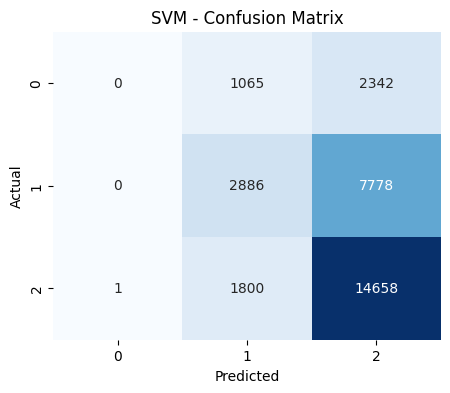

In [60]:
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1, max_iter=2000, random_state=42)   # adjust C manually
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred)
print("SVM Accuracy:", acc_svm)
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Store accuracy in results dictionary
results["SVM"] = acc_svm

Naive Bayes Accuracy: 0.11375696036685227
Classification Report:
               precision    recall  f1-score   support

         <30       0.11      1.00      0.20      3407
         >30       0.46      0.01      0.01     10664
          NO       0.54      0.00      0.00     16459

    accuracy                           0.11     30530
   macro avg       0.37      0.33      0.07     30530
weighted avg       0.46      0.11      0.03     30530



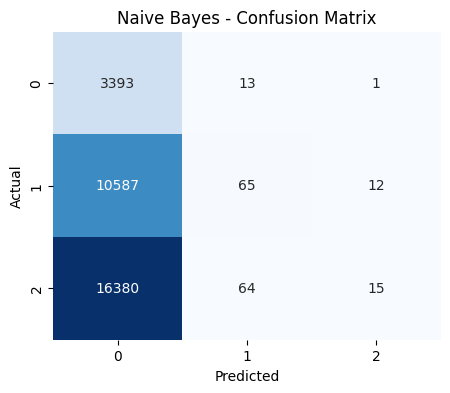

In [61]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB(var_smoothing=1e-9)   # adjust var_smoothing manually
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", acc_nb)
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Store accuracy in results dictionary
results["Naive Bayes"] = acc_nb

Random Forest Accuracy: 0.6019980347199476
Classification Report:
               precision    recall  f1-score   support

         <30       0.44      0.02      0.04      3407
         >30       0.53      0.45      0.48     10664
          NO       0.64      0.82      0.72     16459

    accuracy                           0.60     30530
   macro avg       0.53      0.43      0.41     30530
weighted avg       0.57      0.60      0.56     30530



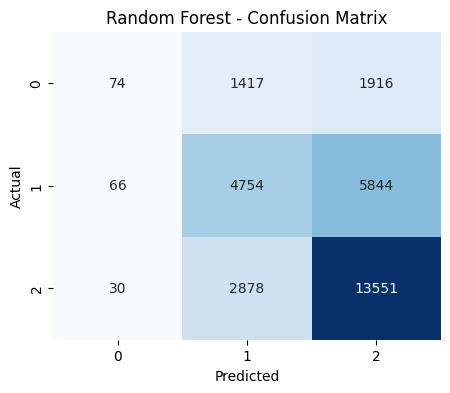

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)  # adjust n_estimators/max_depth
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", acc_rf)
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ Store accuracy in results dictionary
results["Random Forest"] = acc_rf


Model Comparison:
                  Model  Accuracy
0                  KNN  0.506485
1        Decision Tree  0.579561
2  Logistic Regression  0.576155
3                  SVM  0.574648
4          Naive Bayes  0.113757
5        Random Forest  0.601998


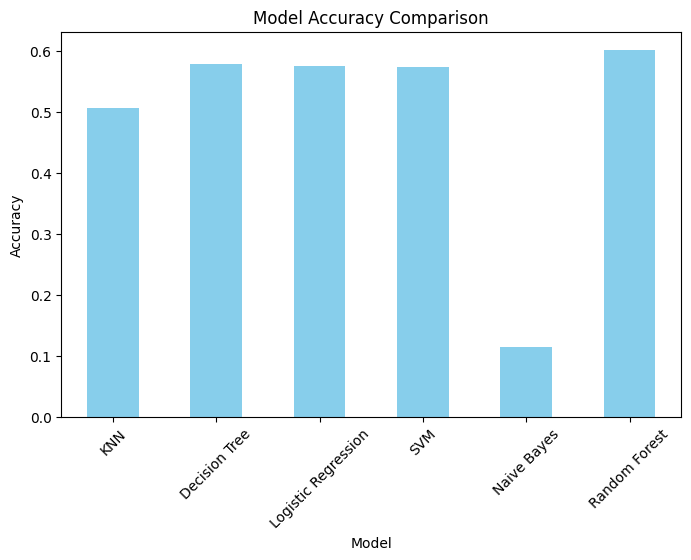


✅ Best Model: Random Forest with Accuracy = 0.6020


In [66]:
import pandas as pd

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
print("\nModel Comparison:\n", results_df)

# Plot bar chart
results_df.set_index('Model').plot(kind='bar', figsize=(8,5), legend=False, color="skyblue")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Print best model
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]
print(f"\n✅ Best Model: {best_model_name} with Accuracy = {best_accuracy:.4f}")

In [64]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\n✅ Best model is {best_model['Model']} with accuracy {best_model['Accuracy']:.4f}")


✅ Best model is Decision Tree with accuracy 0.5796
